# Physical Activity - ENMO Analysis 
**GitHub repository:* [My GitHub repository](https://github.com/Aminata-MOUSSA/HAH913E-Physical-Activity-00.git)

**Team member:**
- Aminata MOUSSA
- Ndiaya DIENG
- Ifetayo HOUESSIONON 
- Noam GREA 

## Objective 
The objective of this notebook is to analyse raw accelerometer data recorded from an Axivity AX3 accelerometer worn on the non-dominant wrist.
The ENMO will be calculated from the three acceleration axes (x, y, z) and integrated over different epoch lenghts: 10s, 30s and 60s.

## Import libraries

**Objective:** Load the tools used in this notebook.

`pandas` reads and handles tables. `numpy` is used for calculations. `matplotlib` will be used for plots.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## Data import

**Objective:** Read the sensor data from `0_z.csv`.

`pd.read_csv()` loads the file into `df`. The first line starts with `#`, so `comment="#"` skips it. `df.head()` shows the first five rows.

In [8]:
df= pd.read_csv("0_z.csv", comment="#")
df.head()

,t,x,y,z
0,0.00,-0.0938,-0.0156,0.9531
1,0.02,-0.0938,-0.0156,0.9531
2,0.04,-0.0938,-0.0156,0.9531
3,0.06,-0.0938,-0.0156,0.9531
4,0.08,-0.0938,-0.0156,0.9531


## Data inspection

The next four steps check that the data is ready to use.

### Step 1: Dataset overview

**Objective:** See how much data there is and which columns it contains.

`df.shape` gives the number of rows and columns. `df.columns` lists the column names. `df.head()` shows the first five rows.

In [9]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])
print("Column names:", list(df.columns))
df.head()

Number of rows: 21000
Number of columns: 4
Column names: ['t', 'x', 'y', 'z']


,t,x,y,z
0,0.00,-0.0938,-0.0156,0.9531
1,0.02,-0.0938,-0.0156,0.9531
2,0.04,-0.0938,-0.0156,0.9531
3,0.06,-0.0938,-0.0156,0.9531
4,0.08,-0.0938,-0.0156,0.9531


### Step 2: Check required columns

**Objective:** Make sure the file has `t`, `x`, `y`, and `z` before using them.

`required_columns` lists these columns. The code checks that none are missing. If one is missing, it stops and shows an error.

In [10]:
required_columns = ["t", "x", "y", "z"]
missing_columns = [column for column in required_columns if column not in df.columns]

if missing_columns:
    raise ValueError(f"Missing required columns: {missing_columns}")

print("All required columns are present:", required_columns)

All required columns are present: ['t', 'x', 'y', 'z']


### Step 3: Check data types and missing values

**Objective:** Check that the measurements are numbers and that none are missing.

`pd.to_numeric()` converts values to numbers. Text that cannot be converted becomes missing. `isna().sum()` counts missing values. The code stops if any are found.

In [29]:
print("Original data types:")
print(df[required_columns].dtypes)

df[required_columns] = df[required_columns].apply(pd.to_numeric, errors="coerce")
missing_values = df[required_columns].isna().sum()

print("Missing or non-numeric values:")
print(missing_values)

if missing_values.any():
    raise ValueError("Some required values are missing or non-numeric.")

Original data types:
t    float64
x    float64
y    float64
z    float64
dtype: object
Missing or non-numeric values:
t    0
x    0
y    0
z    0
dtype: int64


### Step 4: Check the time sequence

**Objective:** Check that timestamps are in order and not repeated.

`is_monotonic_increasing` checks the order. `duplicated().sum()` counts repeated times. The code stops if the times are out of order or repeated.

In [12]:
time_is_increasing = df["t"].is_monotonic_increasing
duplicate_times = df["t"].duplicated().sum()

print("Time is increasing:", time_is_increasing)
print("Duplicate time values:", duplicate_times)

if not time_is_increasing or duplicate_times > 0:
    raise ValueError("The time column must increase without duplicate values.")

Time is increasing: True
Duplicate time values: 0


## Sampling frequency

The next four steps find the sampling frequency and check the timing.

### Step 1: Find the time intervals

**Objective:** Calculate the time between each pair of consecutive measurements.

`diff()` finds each time difference. `dropna()` removes the first result because it has no previous measurement. `head()` displays the first few intervals.

In [14]:
time_intervals = df["t"].diff().dropna()

if time_intervals.empty:
    raise ValueError("At least two time measurements are required.")

time_intervals.head()

1    0.02
2    0.02
3    0.02
4    0.02
5    0.02
Name: t, dtype: float64

### Step 2: Find the typical interval

**Objective:** Find one representative time interval for the measurements.

`median()` returns the middle value of all the time intervals. We store it in `dt`.

In [15]:
dt = time_intervals.median()
print(f"Typical time interval: {dt:.4f} s")

Typical time interval: 0.0200 s


### Step 3: Calculate the frequency

**Objective:** Convert the time interval into measurements per second.

The frequency is the inverse of the interval: `fs = 1 / dt`. Frequency is measured in hertz (Hz).

In [16]:
fs = 1 / dt
print(f"Sampling frequency: {fs:.2f} Hz")

Sampling frequency: 50.00 Hz


### Step 4: Check regularity

**Objective:** Check whether the time interval stays the same throughout the recording.

`np.isclose()` compares each interval with `dt`, allowing for tiny rounding differences. The code counts intervals that do not match.

In [17]:
irregular_count = int(
    (~np.isclose(time_intervals, dt, rtol=1e-3, atol=1e-9)).sum()
)
print(f"Irregular intervals: {irregular_count} / {len(time_intervals)}")

Irregular intervals: 0 / 20999


## ENMO calculation 
The Euclidean Norm Minus One (ENMO) is calculated from the three acceleration axes (x, y, z):

ENMO = √(x² + y² + z²) - 1

A function is defined to make the ENMO calculation reusable and easier to apply to the acceleration data.

In [18]:
df["enmo"] = np.sqrt(
    df["x"]**2 +
    df["y"]**2 +
    df["z"]**2
) - 1

df["enmo"].describe()

count    21000.000000
mean         0.016746
std          0.594757
min         -0.889493
25%         -0.042168
50%         -0.042168
75%         -0.013368
max         12.784616
Name: enmo, dtype: float64

In [19]:
def calculate_enmo(x, y, z):
    return np.sqrt(x**2 + y**2 + z**2) - 1

In [20]:
df["enmo"] = calculate_enmo(df["x"], df["y"], df["z"])


In [21]:
df[["t", "enmo"]].head()

,t,enmo
0,0.00,-0.042168
1,0.02,-0.042168
2,0.04,-0.042168
3,0.06,-0.042168
4,0.08,-0.042168


### ENMO integration over epochs
The ENMO values are averaged over different epoch lengths (10 s, 30 s and 60 s) to study the effect of temporal aggregation on physical activity measurements.

At a sampling frequency of 50 Hz, the 10 s, 30 s and 60 s epochs correspond to 500, 1500 and 3000 samples, respectively.

In [22]:
# Epoch durations in seconds
epoch_10s = 10
epoch_30s = 30
epoch_60s = 60

# Number of samples per epoch
samples_10s = int(fs * epoch_10s)
samples_30s = int(fs * epoch_30s)
samples_60s = int(fs * epoch_60s)

# Integrated ENMO
integrated_enmo_10s = (
    df["enmo"]
    .groupby(df.index // samples_10s)
    .sum()
    * epoch_10s / 60
)

integrated_enmo_30s = (
    df["enmo"]
    .groupby(df.index // samples_30s)
    .sum()
    * epoch_30s / 60
)

integrated_enmo_60s = (
    df["enmo"]
    .groupby(df.index // samples_60s)
    .sum()
    * epoch_60s / 60
)

print("Number of 10 s epochs:", len(integrated_enmo_10s))
print("Number of 30 s epochs:", len(integrated_enmo_30s))
print("Number of 60 s epochs:", len(integrated_enmo_60s))

Number of 10 s epochs: 42
Number of 30 s epochs: 14
Number of 60 s epochs: 7


## ENMO Visualization
The ENMO values integrated over 10s, 30s and 60s epochs are visualized as a function of time to compare the effect of the different epoch lengths.

In [23]:
def plot_integrated_enmo(df, epoch, fs):
    # Nombre d'échantillons par epoch
    samples = int(fs * epoch)

    # ENMO intégré
    integrated_enmo = df["enmo"].groupby(df.index // samples).sum() * epoch / 60

    # Temps en minutes
    time_min = df["t"] / 60
    time_epoch = np.arange(len(integrated_enmo)) * epoch / 60

    # Création des deux graphiques (axe x partagé)
    fig, ax = plt.subplots(2, 1, sharex=True)

    # Graphique 1 : ENMO intégré
    ax[0].bar(time_epoch, integrated_enmo, width=(epoch / 60) * 0.95,
              align="edge", color="gray", alpha=0.7)
    ax[0].set_title(f"ENMO integrated over {epoch:.1f} s intervals")
    ax[0].set_ylabel("Integrated ENMO (g.min)")

    # Graphique 2 : ENMO au cours du temps
    ax[1].plot(time_min, df["enmo"], alpha=0.5)
    ax[1].set_title("ENMO over Time")
    ax[1].set_xlabel("Time (minutes)")
    ax[1].set_ylabel("ENMO (g)")

    plt.tight_layout()
    plt.show()

    return integrated_enmo

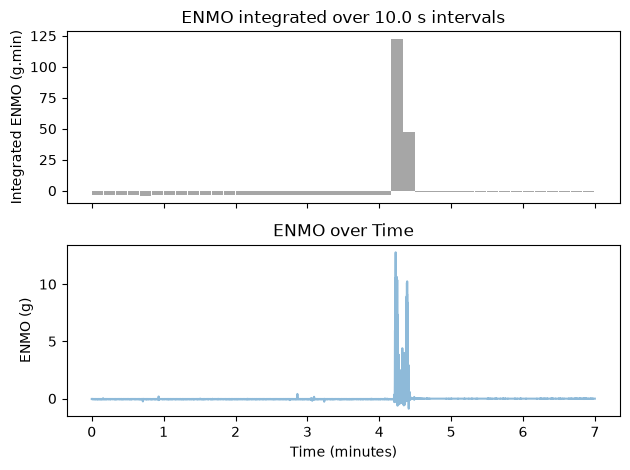

In [24]:
integrated_enmo_10s = plot_integrated_enmo(df, 10, fs)

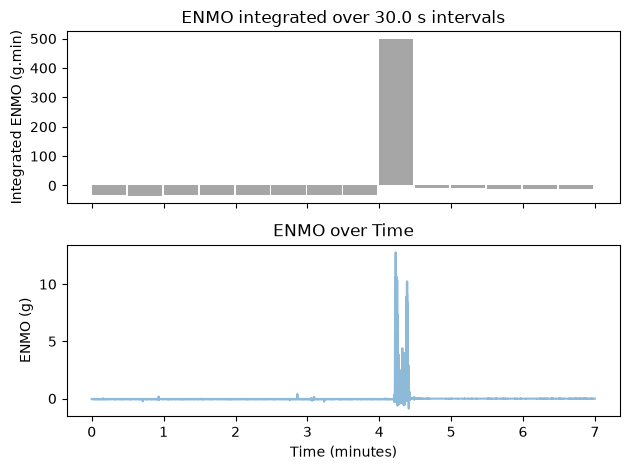

In [25]:
integrated_enmo_30s = plot_integrated_enmo(df, 30, fs)

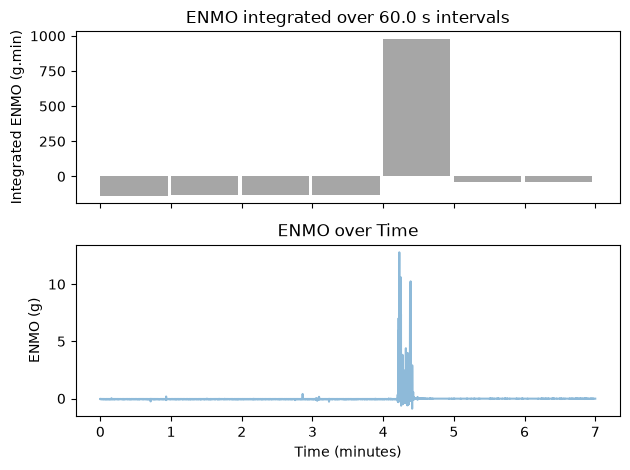

In [27]:
integrated_enmo_60s = plot_integrated_enmo(df, 60, fs)